# 02 — Exploration des schémas de placement

Phase 2 : on compare les 5 schémas de placement de capteurs sur le même
champ. Chaque capteur retourne une **probabilité de présence** dans `[0, 1]`
(fraction de positifs sur ``n_observations`` mesures temporelles, modèle
binomial). Pour chaque schéma on visualise les positions colorées par leur
lecture et on regarde la distance moyenne au capteur le plus proche.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

from aphid_spatial.simulation import (
    Field,
    FieldConfig,
    SensorConfig,
    place_sensors,
    simulate_field,
)
from aphid_spatial.visualization.maps import plot_sensors

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

data_path = Path("../data/simulated/field_default.npz")
if data_path.exists():
    field = Field.load(data_path)
else:
    field = simulate_field(FieldConfig(seed=42))

In [2]:
schemes = ["uniform", "grid", "stratified", "edge_biased", "poisson_disk"]
all_readings = {}
for s in schemes:
    all_readings[s] = place_sensors(
        field, SensorConfig(n_sensors=20, placement=s, n_observations=50, seed=2024)
    )

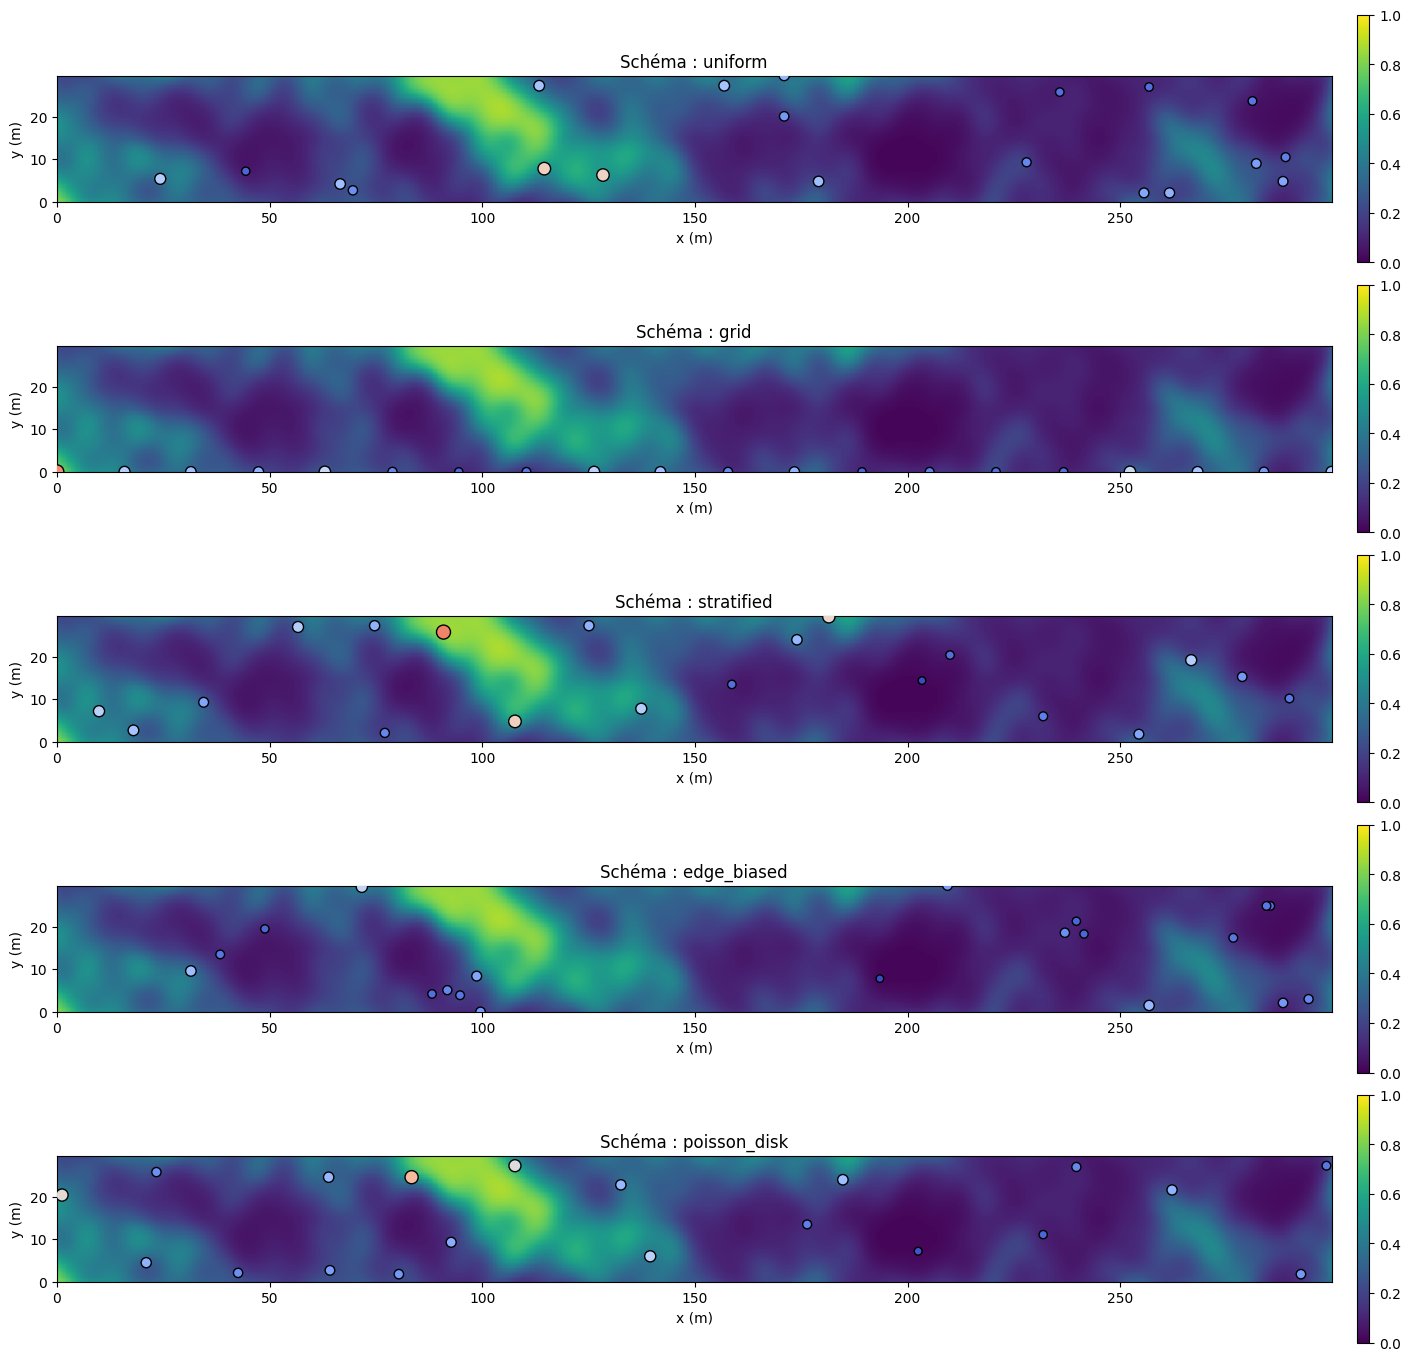

In [3]:
fig, axes = plt.subplots(len(schemes), 1, figsize=(14, 2.7 * len(schemes)), constrained_layout=True)
for ax, s in zip(axes, schemes, strict=True):
    plot_sensors(all_readings[s], field, ax=ax, title=f"Schéma : {s}")
fig.savefig(FIG_DIR / "02_exploration_schemes.png", dpi=150)
plt.show()

## Statistiques par schéma

- **obs_moyenne** : moyenne des observations probabilistes des capteurs.
- **obs_max** : capteur avec la plus forte présence détectée.
- **dist_moyenne** : distance moyenne, depuis chaque plant, au capteur le
  plus proche (en mètres). Plus c'est petit, mieux le champ est couvert.

In [4]:
rows = []
for s, r in all_readings.items():
    tree = cKDTree(r.coords)
    dist, _ = tree.query(field.coords, k=1)
    rows.append(
        {
            "scheme": s,
            "obs_moyenne": float(r.obs.mean()),
            "obs_max": float(r.obs.max()),
            "prob_local_moyenne": float(r.prob_local.mean()),
            "dist_moyenne_m": float(dist.mean()),
            "dist_max_m": float(dist.max()),
        }
    )
df = pd.DataFrame(rows)
df.insert(1, "prevalence_vraie", float(field.presence.mean()))
df.insert(2, "p_vraie_moyenne", float(field.prob.mean()))
df

,scheme,prevalence_vraie,p_vraie_moyenne,obs_moyenne,obs_max,prob_local_moyenne,dist_moyenne_m,dist_max_m
0,uniform,0.23929,0.239978,0.242,0.58,0.240542,12.209452,34.365390
1,grid,0.23929,0.239978,0.255,0.78,0.265534,15.858440,30.707165
2,stratified,0.23929,0.239978,0.282,0.80,0.288935,10.115319,26.044769
3,edge_biased,0.23929,0.239978,0.147,0.40,0.155808,16.255023,51.965854
4,poisson_disk,0.23929,0.239978,0.250,0.66,0.254541,10.166708,25.360205


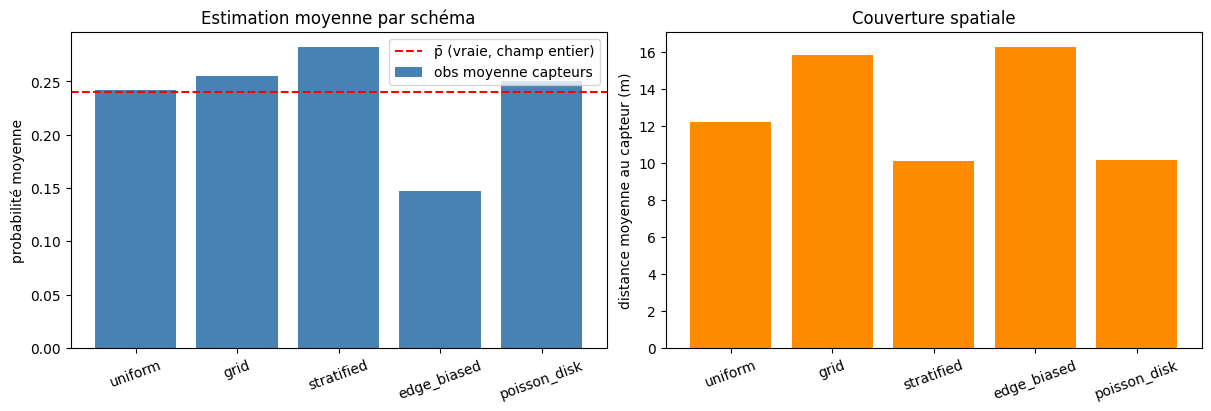

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].bar(df["scheme"], df["obs_moyenne"], color="steelblue", label="obs moyenne capteurs")
axes[0].axhline(float(field.prob.mean()), color="red", linestyle="--", label="p̄ (vraie, champ entier)")
axes[0].set_ylabel("probabilité moyenne")
axes[0].set_title("Estimation moyenne par schéma")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(df["scheme"], df["dist_moyenne_m"], color="darkorange")
axes[1].set_ylabel("distance moyenne au capteur (m)")
axes[1].set_title("Couverture spatiale")
axes[1].tick_params(axis="x", rotation=20)
fig.savefig(FIG_DIR / "02_exploration_stats.png", dpi=150)
plt.show()